In [34]:
from sklearn.datasets import make_classification
import numpy as np 
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
x, y = make_classification(n_samples=5000, n_features=50, random_state=0)

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [4]:
def loss(w, xi, yi, lamda=0): # function to compute log loss for a single point w/ L2 regularization
    loss = -yi * np.log(sigmoid(w @ xi)) - (1-yi)*np.log(1-sigmoid(w @ xi)) + ((lamda/2)*np.sum(w**2))
    return loss

In [5]:
def cost(w, x, y, lamda=0): # function to compute avg loss across all samples (aka cost) w/ L2 regularization 
    m = len(y)
    cost = 0
    for i in range(m):
        cost += loss(w, x[i], y[i], lamda)
    return 1/m * cost

In [6]:
def grad_loss(w, xi, yi, lamda=0): # gradient of loss function for single point w/ respect to w 
    grad_loss = (sigmoid(w @ xi) - yi) * xi + (lamda * w)
    return grad_loss

In [7]:
def grad_cost(w, x, y, lamda=0): # gradient of cost function w/ respect to w 
    m = len(y)
    grad_cost = 0 
    for i in range(m): 
        grad_cost += grad_loss(w, x[i], y[i], lamda) 
    return 1/m * grad_cost

In [8]:
def stochastic_gd_fixed(w, x, y, t, epochs, lamda=0):
    m = len(y)
    costs = []
    grad_norms = []
    for epoch in range(epochs): 
        for j in range(m): 
            i = np.random.randint(0,m) # find a random point for gradient computation 
            gradient = grad_loss(w, x[i], y[i], lamda) # compute gradient for that point  
            w = w - t*gradient # update w 
        
        costs.append(cost(w, x, y, lamda)) # save cost at each epoch(iteration)
        grad_norms.append(np.linalg.norm(grad_cost(w, x, y, lamda)))
    
    final_cost = costs[-1]
    final_grad_norm = grad_norms[-1]
    return costs, grad_norms, final_cost, final_grad_norm

In [9]:
def stochastic_gd_decreasing(w, x, y, t, epochs, lamda=0):
    m = len(y)
    costs = []
    grad_norms = []
    k = 1
    for epoch in range(epochs): 
        for j in range(m):
            i = np.random.randint(0, m) # find a random point for gradient computation 
            if lamda > 0: 
                step = 1 /(lamda*k) #decreasing step size for strongly convex setting 
            else: 
                step = t / np.sqrt(k) #decreasing step size for convex setting 
            gradient = grad_loss(w, x[i], y[i], lamda) # compute gradient for that point 
            w = w - step*gradient 
            k += 1
            
        costs.append(cost(w, x, y, lamda))
        grad_norms.append(np.linalg.norm(grad_cost(w, x, y, lamda)))
        
    final_cost = costs[-1]
    final_grad_norm = grad_norms[-1]
    return costs, grad_norms, final_cost, final_grad_norm

In [10]:
# SGD on convex setting (no L2 regularization) fixed step size AND decreasing step size 
lamda=0
m = len(y) 
L = np.sum(np.sum(x**2, axis=1)) / (4 * m) # lipshitz constant for logistic regression w log loss 
t = 1/L # step size 
initial_weights = np.zeros(x.shape[1]) # set initial weights to 0 (20 weights total) 

costs_fixed_convex, gradnorms_fixed_convex, final_cost_fixed_convex, final_grad_fixed_convex = stochastic_gd_fixed(initial_weights.copy(), x, y, t, epochs=100, lamda=0)
costs_decreasing_convex, gradnorms_decreasing_convex, final_cost_decreasing_convex, final_grad_decreasing_convex = stochastic_gd_decreasing(initial_weights.copy(), x, y, t, epochs=100, lamda=0)
print(f"Convex with fixed step size : final cost = {final_cost_fixed_convex}, final grad norm = {final_grad_fixed_convex}")
print(f"Convex with decreasing step size: final cost = {final_cost_decreasing_convex}, final grad norm = {final_grad_decreasing_convex}")

Convex with fixed step size : final cost = 0.1798986720942639, final grad norm = 0.055910271013153705
Convex with decreasing step size: final cost = 0.1308027035143311, final grad norm = 0.004298911887696215


In [11]:
# SGD on strongly convex setting (w/ L2 regularization) fixed step size AND decreasing step size 
lamda=0.1
L = (np.sum(np.sum(x**2, axis=1)) / (4 * m)) + lamda  # lipshitz constant for logistic regression w/ log loss w/ L2 regularization 
t = 1/L # step size 
initial_weights = np.zeros(x.shape[1]) # set initial weights to 0 (20 weights total) 

costs_fixed_strong_con, gradnorms_fixed_strong_con, final_cost_fixed_strong_con, final_grad_strong_con = stochastic_gd_fixed(initial_weights.copy(), x, y, t, epochs=100, lamda=lamda)
costs_decreasing_strong_con, gradnorms_decreasing_strong_con, final_cost_decreasing_strong_con, final_grad_decreasing_strong_con = stochastic_gd_decreasing(initial_weights.copy(), x, y, t, epochs=100, lamda=lamda)
print(f"Strongly Convex with fixed step size: final cost = {final_cost_fixed_strong_con}, final grad norm = {final_grad_strong_con}")
print(f"Strongly Convex with decreasing step size: final cost = {final_cost_decreasing_strong_con}, final grad norm = {final_grad_decreasing_strong_con}")

Strongly Convex with fixed step size: final cost = 0.3795591707764732, final grad norm = 0.16625950587029756
Strongly Convex with decreasing step size: final cost = 0.31878589473581537, final grad norm = 0.0020425070177872186


In [12]:
def svrg(w, x, y, t, epochs, lamda=0):
    m = len(y)
    costs = []
    grad_norms = []
    for epoch in range(epochs):
        w_snapshot = w.copy() # at start of epoch freeze current weights and capture snapshot  
        full_grad_snapshot = grad_cost(w_snapshot, x, y, lamda) # compute full gradient at snapshot weights 
        for j in range(m):
            i = np.random.randint(0, m) 
            grad_current = grad_loss(w, x[i], y[i], lamda) # compute gradient for single point at current weights 
            grad_snapshot = grad_loss(w_snapshot, x[i], y[i], lamda)  # compute gradient for single point at snapshot weights 
            v = grad_current - grad_snapshot + full_grad_snapshot # variance reduced gradient
            w = w - t * v                            
        
        costs.append(cost(w, x, y, lamda))
        grad_norms.append(np.linalg.norm(grad_cost(w, x, y, lamda)))
    
    final_cost = costs[-1]
    final_grad_norm = grad_norms[-1]
    return costs, grad_norms, final_cost, final_grad_norm

In [13]:
# SVRG on Convex Setting (no L2 regularization)
lamda = 0
m = len(y)
L = np.sum(np.sum(x**2, axis=1)) / (4 * m)
t = 1 / (10 * L) # SVRG uses fixed step size 1/10L
initial_weights = np.zeros(x.shape[1])

costs_svrg_convex, gradnorms_svrg_convex, final_cost_svrg_convex, final_grad_svrg_convex = svrg(initial_weights.copy(), x, y, t, epochs=100, lamda=lamda)
print(f"SVRG Convex: final cost = {final_cost_svrg_convex}, final grad norm = {final_grad_svrg_convex}")

SVRG Convex: final cost = 0.13034284528315787, final grad norm = 3.2529130359531966e-14


In [14]:
# SVRG on Strongly Convex Setting (w/L2 regularization)
lamda = 0.1
L = np.sum(np.sum(x**2, axis=1)) / (4 * m) + lamda
t = 1 / (10 * L) # SVRG uses fixed step size 1/10L
initial_weights = np.zeros(x.shape[1])

costs_svrg_strong_con, gradnorms_svrg_strong_con, final_cost_svrg_strong_con, final_grad_svrg_strong_con = svrg(initial_weights.copy(), x, y, t, epochs=100, lamda=lamda)
print(f"SVRG Strongly Convex: final cost = {final_cost_svrg_strong_con}, final grad norm = {final_grad_svrg_strong_con}")

SVRG Strongly Convex: final cost = 0.318776865074814, final grad norm = 7.684190411465278e-16


In [15]:
def saga(w, x, y, t, epochs, lamda=0):
    m = len(y)
    costs = []
    grad_norms = []
    grad_table = np.array([grad_loss(w, x[i], y[i], lamda) for i in range(m)]) # gradient table storing gradient of loss at each point 
    avg_grad_table = np.mean(grad_table, axis=0) # avg of stored gradient 
    for epoch in range(epochs):
        for j in range(m):
            i = np.random.randint(0, m)
            grad_new = grad_loss(w, x[i], y[i], lamda) # compute new gradient for current point i 
            w = w - t * (grad_new - grad_table[i] + avg_grad_table) # update w 
            avg_grad_table = avg_grad_table + ((1/m)*(grad_new - grad_table[i])) # update avg of stored gradient 
            grad_table[i] = grad_new #update gradient for current point in gradient table
        
        costs.append(cost(w, x, y, lamda))
        grad_norms.append(np.linalg.norm(grad_cost(w, x, y, lamda)))
    
    final_cost = costs[-1]
    final_grad_norm = grad_norms[-1]
    return costs, grad_norms, final_cost, final_grad_norm

In [16]:
# SAGA on Convex Setting (no L2 regularization)
lamda = 0
m = len(y)
L = np.sum(np.sum(x**2, axis=1)) / (4 * m)
t = 1 / (3 * L) # SAGA uses fixed step size 1/3L
initial_weights = np.zeros(x.shape[1])

costs_saga_convex, gradnorms_saga_convex, final_cost_saga_convex, final_grad_saga_convex = saga(initial_weights.copy(), x, y, t, epochs=100, lamda=lamda)
print(f"SAGA Convex: final cost = {final_cost_saga_convex}, final grad norm = {final_grad_saga_convex}")

SAGA Convex: final cost = 0.1303428452831581, final grad norm = 1.7205884504863541e-15


In [17]:
# SAGA on Strongly Convex Setting (w/L2 regularization)
lamda = 0.1
L = np.sum(np.sum(x**2, axis=1)) / (4 * m) + lamda
t = 1 / (3 * L) # SAGA uses fixed step size 1/3L
initial_weights = np.zeros(x.shape[1])

costs_saga_strong_con, gradnorms_saga_strong_con, final_cost_saga_strong_con, final_grad_saga_strong_con = saga(initial_weights.copy(), x, y, t, epochs=100, lamda=lamda)
print(f"SAGA Strongly Convex: final cost = {final_cost_saga_strong_con}, final grad norm = {final_grad_saga_strong_con}")

SAGA Strongly Convex: final cost=0.3187768650748141, final grad norm = 2.8254300899620536e-15


In [18]:
def sarah(w, x, y, t, epochs, inner_loop_size, lamda=0):
    m = len(y)
    costs = []
    grad_norms = []
    for epoch in range(epochs):
        w0 = w.copy() # save weights at start of epoch as w0                            
        full_grad = grad_cost(w0, x, y, lamda) #compute full grad at w0 
        w = w0 - t*full_grad #update w using full grad at w0 
        
        w_t_minus_1 = w0.copy()                         
        full_grad_t_minus_1 = full_grad.copy()                              
        
        inner_iterates = [w.copy()] #store inner iterates to pick random at end of loop 
        
        for j in range(1, inner_loop_size):
            i = np.random.randint(0, m)        
            grad_current = grad_loss(w, x[i], y[i], lamda) #compute gradient for single point i at current w
            grad_prev = grad_loss(w_t_minus_1, x[i], y[i], lamda) # compute gradient at previous w (w_t-1)
            full_grad_t_minus_1 = grad_current - grad_prev + full_grad_t_minus_1 #update new full_grad_t-1 
            w_t_minus_1 = w.copy() #update new w_t-1 = w_t                     
            w = w - t*full_grad_t_minus_1 #update w_t+1 = w_t-t*full_grad_t-1            
            inner_iterates.append(w.copy())
        
        w = inner_iterates[np.random.randint(0, len(inner_iterates))]
        costs.append(cost(w, x, y, lamda))
        grad_norms.append(np.linalg.norm(grad_cost(w, x, y, lamda)))
    
    final_cost = costs[-1]
    final_grad_norm = grad_norms[-1]
    return costs, grad_norms, final_cost, final_grad_norm

In [19]:
# SARAH on Convex Setting (no L2 regularization)
lamda = 0
m = len(y)
L = np.sum(np.sum(x**2, axis=1)) / (4 * m)
t = 1 / L # SARAH uses fixed step size 1/L
inner_loop_size = 2 * m 
initial_weights = np.zeros(x.shape[1])

costs_sarah_convex, gradnorms_sarah_convex, final_cost_sarah_convex, final_grad_sarah_convex = sarah(initial_weights.copy(), x, y, t, epochs=100, inner_loop_size=inner_loop_size, lamda=lamda)
print(f"SARAH Convex: final cost = {final_cost_sarah_convex}, final grad norm = {final_grad_sarah_convex}")

/var/folders/k0/szzfrvxj5h349vrf8y8j_wg00000gn/T/ipykernel_33840/3852723983.py:2: RuntimeWarning: divide by zero encountered in log
  loss = -yi * np.log(sigmoid(w @ xi)) - (1-yi)*np.log(1-sigmoid(w @ xi)) + ((lamda/2)*np.sum(w**2))
/var/folders/k0/szzfrvxj5h349vrf8y8j_wg00000gn/T/ipykernel_33840/3852723983.py:2: RuntimeWarning: invalid value encountered in scalar multiply
  loss = -yi * np.log(sigmoid(w @ xi)) - (1-yi)*np.log(1-sigmoid(w @ xi)) + ((lamda/2)*np.sum(w**2))


SARAH Convex: final cost=0.13034284528315793, final grad norm=2.440114611335058e-14


In [20]:
# SARAH on Strongly Convex Setting (w/L2 regularization)
lamda = 0.1
L = np.sum(np.sum(x**2, axis=1)) / (4 * m) + lamda
t = 1 / L
inner_loop_size = 2 * m
initial_weights = np.zeros(x.shape[1])

costs_sarah_strong_con, gradnorms_sarah_strong_con, final_cost_sarah_strong_con, final_grad_sarah_strong_con = sarah(initial_weights.copy(), x, y, t, epochs=100, inner_loop_size=inner_loop_size, lamda=lamda)
print(f"SARAH Strongly Convex: final cost = {final_cost_sarah_strong_con}, final grad norm = {final_grad_sarah_strong_con}")

SARAH Strongly Convex: final cost=0.3187768650748141, final grad norm=3.5532425602049524e-14


In [21]:
# We use Newtons Method to get the true optimal value of the cost function for both settings 
result_convex = minimize(fun=lambda w: cost(w, x, y, lamda=0), x0=np.zeros(x.shape[1]), method='Newton-CG', jac=lambda w: grad_cost(w, x, y, lamda=0))
optimal_cost_convex = result_convex.fun
print(f"Optimal Cost for Convex setting = {optimal_cost_convex}")

result_strong_con = minimize(fun=lambda w: cost(w, x, y, lamda=0.1), x0=np.zeros(x.shape[1]), method='Newton-CG', jac=lambda w: grad_cost(w, x, y, lamda=0.1))
optimal_cost_strong_con = result_strong_con.fun
print(f"Optimal Cost for Strongly Convex setting = {optimal_cost_strong_con}")

Optimal Cost for Convex setting = 0.1303428452831786
Optimal Cost for Strongly Convex setting = 0.3187768650748164


In [22]:
def epochs_to_converge(costs, optimal_cost, epsilon=1e-3):
    for epoch, cost in enumerate(costs):
        if cost - optimal_cost < epsilon:
            return epoch
    return None  

print("Epochs to converge for Convex setting:")
print(f"SGD Fixed: {epochs_to_converge(costs_fixed_convex, optimal_cost_convex)}")
print(f"SGD Decreasing: {epochs_to_converge(costs_decreasing_convex, optimal_cost_convex)}")
print(f"SVRG: {epochs_to_converge(costs_svrg_convex, optimal_cost_convex)}")
print(f"SAGA: {epochs_to_converge(costs_saga_convex, optimal_cost_convex)}")
print(f"SARAH: {epochs_to_converge(costs_sarah_convex, optimal_cost_convex)}")


Epochs to converge for Convex setting:
SGD Fixed: None
SGD Decreasing: 55
SVRG: 2
SAGA: 4
SARAH: 12


In [23]:
print("Epochs to converge for Strongly Convex setting:")
print(f"SGD Fixed: {epochs_to_converge(costs_fixed_strong_con, optimal_cost_strong_con)}")
print(f"SGD Decreasing: {epochs_to_converge(costs_decreasing_strong_con, optimal_cost_strong_con)}")
print(f"SVRG: {epochs_to_converge(costs_svrg_strong_con, optimal_cost_strong_con)}")
print(f"SAGA: {epochs_to_converge(costs_saga_strong_con, optimal_cost_strong_con)}")
print(f"SARAH: {epochs_to_converge(costs_sarah_strong_con, optimal_cost_strong_con)}")

Epochs to converge for Strongly Convex setting:
SGD Fixed: None
SGD Decreasing: 1
SVRG: 1
SAGA: 3
SARAH: 5


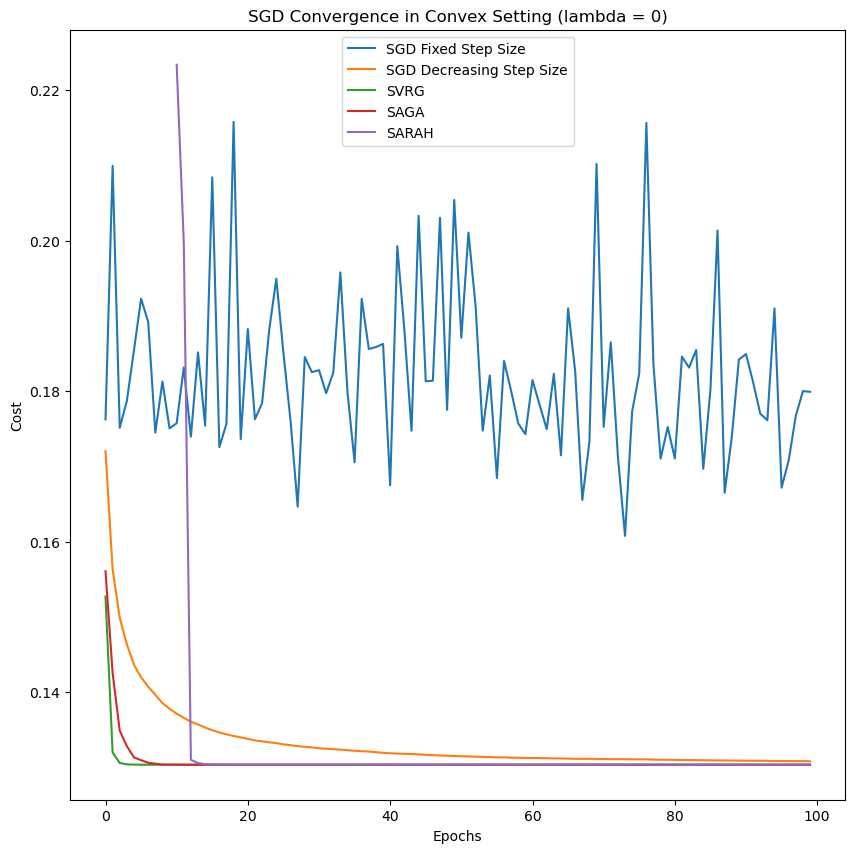

In [24]:
plt.figure(figsize=(10, 10))
plt.plot(costs_fixed_convex, label='SGD Fixed Step Size')
plt.plot(costs_decreasing_convex, label='SGD Decreasing Step Size')
plt.plot(costs_svrg_convex, label='SVRG')
plt.plot(costs_saga_convex, label='SAGA')
plt.plot(costs_sarah_convex, label='SARAH')
plt.title('SGD Convergence in Convex Setting (lambda = 0)')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.legend()
plt.show()

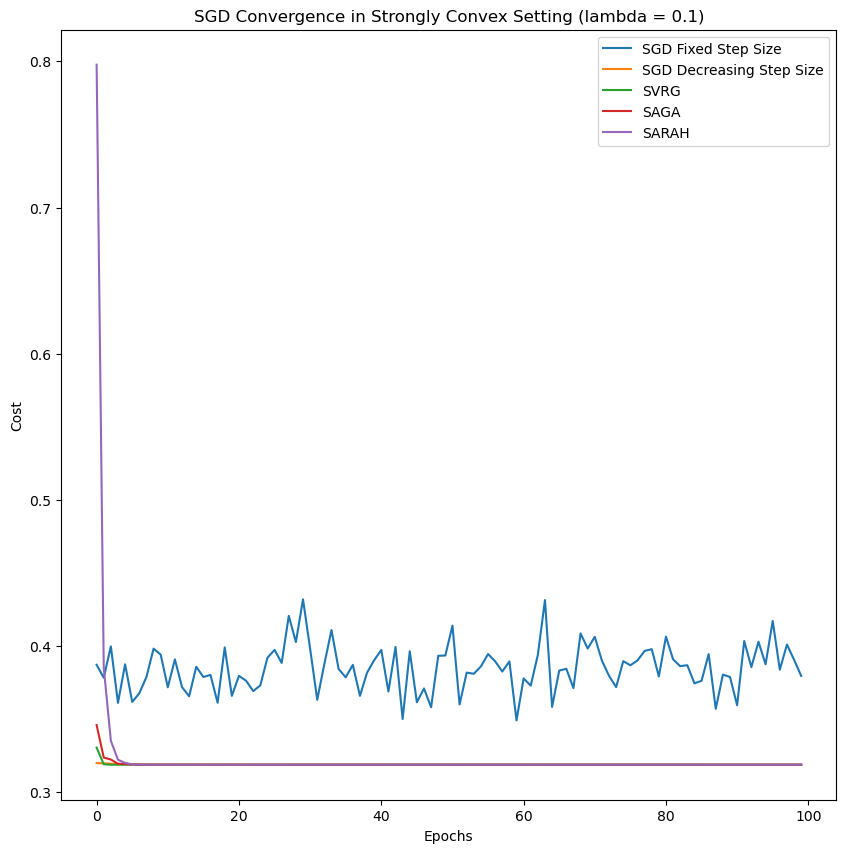

In [25]:
plt.figure(figsize=(10, 10))
plt.plot(costs_fixed_strong_con, label='SGD Fixed Step Size')
plt.plot(costs_decreasing_strong_con, label='SGD Decreasing Step Size')
plt.plot(costs_svrg_strong_con, label='SVRG')
plt.plot(costs_saga_strong_con, label='SAGA')
plt.plot(costs_sarah_strong_con, label='SARAH')
plt.title('SGD Convergence in Strongly Convex Setting (lambda = 0.1)')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.legend()
plt.show()

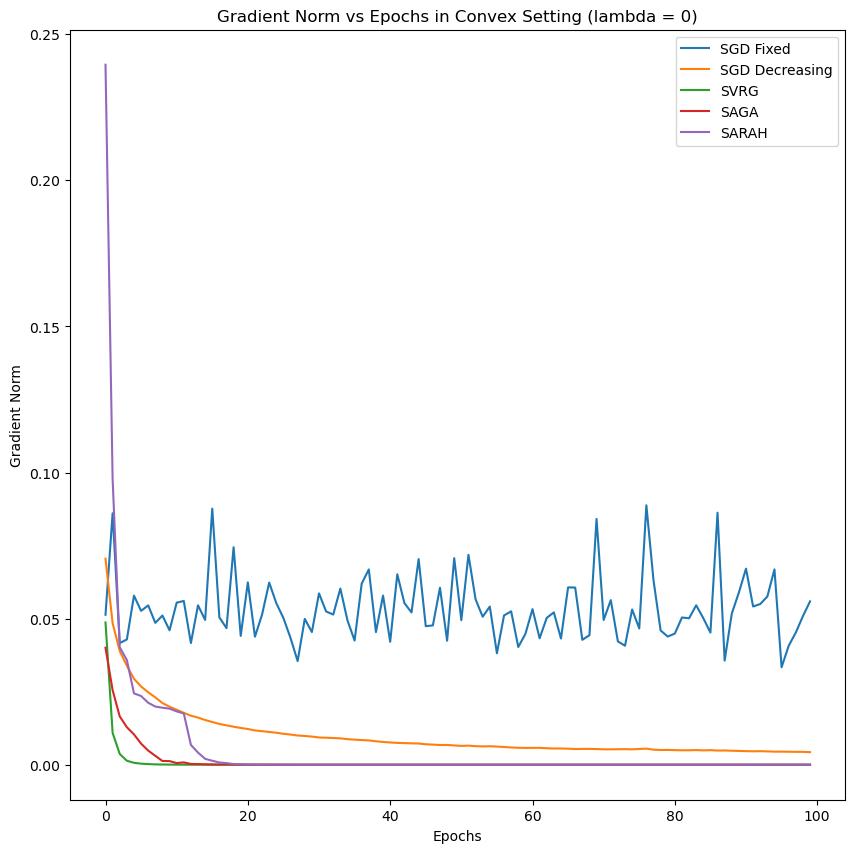

In [26]:
plt.figure(figsize=(10, 10))
plt.plot(gradnorms_fixed_convex, label='SGD Fixed')
plt.plot(gradnorms_decreasing_convex, label='SGD Decreasing')
plt.plot(gradnorms_svrg_convex, label='SVRG')
plt.plot(gradnorms_saga_convex, label='SAGA')
plt.plot(gradnorms_sarah_convex, label='SARAH')
plt.title('Gradient Norm vs Epochs in Convex Setting (lambda = 0)')
plt.xlabel('Epochs')
plt.ylabel('Gradient Norm')
plt.legend()
plt.show()

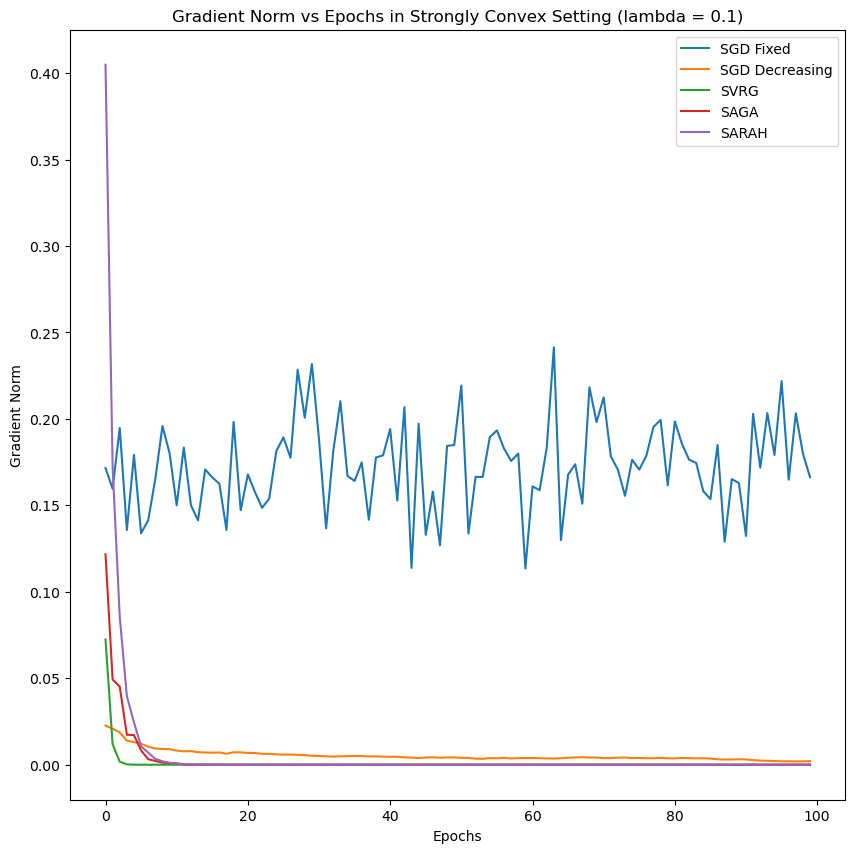

In [27]:
plt.figure(figsize=(10, 10))
plt.plot(gradnorms_fixed_strong_con, label='SGD Fixed')
plt.plot(gradnorms_decreasing_strong_con, label='SGD Decreasing')
plt.plot(gradnorms_svrg_strong_con, label='SVRG')
plt.plot(gradnorms_saga_strong_con, label='SAGA')
plt.plot(gradnorms_sarah_strong_con, label='SARAH')
plt.title('Gradient Norm vs Epochs in Strongly Convex Setting (lambda = 0.1)')
plt.xlabel('Epochs')
plt.ylabel('Gradient Norm')
plt.legend()
plt.show()

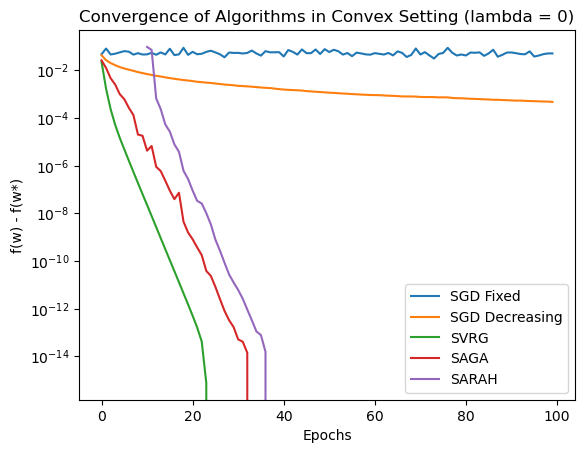

In [28]:
plt.semilogy([cost - optimal_cost_convex for cost in costs_fixed_convex], label='SGD Fixed')
plt.semilogy([cost - optimal_cost_convex for cost in costs_decreasing_convex], label='SGD Decreasing')
plt.semilogy([cost - optimal_cost_convex for cost in costs_svrg_convex], label='SVRG')
plt.semilogy([cost - optimal_cost_convex for cost in costs_saga_convex], label='SAGA')
plt.semilogy([cost - optimal_cost_convex for cost in costs_sarah_convex], label='SARAH')
plt.title('Convergence of Algorithms in Convex Setting (lambda = 0)')
plt.xlabel('Epochs')
plt.ylabel('f(w) - f(w*)')
plt.legend()
plt.show()

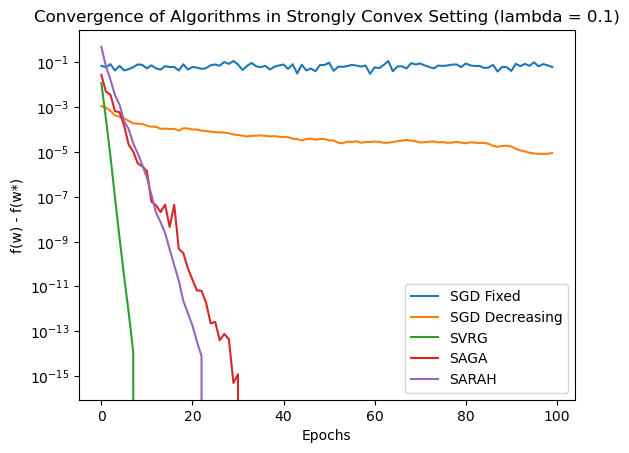

In [33]:
plt.semilogy([cost - optimal_cost_strong_con for cost in costs_fixed_strong_con], label='SGD Fixed')
plt.semilogy([cost - optimal_cost_strong_con for cost in costs_decreasing_strong_con], label='SGD Decreasing')
plt.semilogy([cost - optimal_cost_strong_con for cost in costs_svrg_strong_con], label='SVRG')
plt.semilogy([cost - optimal_cost_strong_con for cost in costs_saga_strong_con], label='SAGA')
plt.semilogy([cost - optimal_cost_strong_con for cost in costs_sarah_strong_con], label='SARAH')
plt.title('Convergence of Algorithms in Strongly Convex Setting (lambda = 0.1)')
plt.xlabel('Epochs')
plt.ylabel('f(w) - f(w*)')
plt.legend()
plt.show()

In [48]:
'''
This code was reformated to produce a cleaner results table using Claude (prompt and output in md file). 
New code from results table is directly from Claude!

data_convex = {
    "Algorithm": ["SGD Fixed", "SGD Decreasing", "SVRG", "SAGA", "SARAH"],
    "Final Cost": [
        final_cost_fixed_convex,
        final_cost_decreasing_convex,
        final_cost_svrg_convex,
        final_cost_saga_convex,
        final_cost_sarah_convex
    ],
    "Optimality Gap": [
        final_cost_fixed_convex - optimal_cost_convex,
        final_cost_decreasing_convex - optimal_cost_convex,
        final_cost_svrg_convex - optimal_cost_convex,
        final_cost_saga_convex - optimal_cost_convex,
        final_cost_sarah_convex - optimal_cost_convex
    ],
    "Final Grad Norm": [
        final_grad_fixed_convex,
        final_grad_decreasing_convex,
        final_grad_svrg_convex,
        final_grad_saga_convex,
        final_grad_sarah_convex
    ],
    "Epochs to Converge": [
        epochs_to_converge(costs_fixed_convex, optimal_cost_convex),
        epochs_to_converge(costs_decreasing_convex, optimal_cost_convex),
        epochs_to_converge(costs_svrg_convex, optimal_cost_convex),
        epochs_to_converge(costs_saga_convex, optimal_cost_convex),
        epochs_to_converge(costs_sarah_convex, optimal_cost_convex)
    ]
}

df_convex = pd.DataFrame(data_convex)
df_convex = df_convex.set_index("Algorithm")

print(f"Convex Setting (lambda = 0)")
print(f"True Optimal Cost f(w*): {optimal_cost_convex}\n")
print(df_convex.to_string(float_format="{:.6e}".format))
'''
print("Convex Setting (lambda = 0)")
print(f"True Optimal Cost f(w*) = {optimal_cost_convex}")
print(f"SGD Fixed:")
print(f"Final Cost = {final_cost_fixed_convex}")
print(f"Optimality Gap = {final_cost_fixed_convex - optimal_cost_convex}")
print(f"Final Grad Norm = {final_grad_fixed_convex}")
print(f"Epochs to Converge = {epochs_to_converge(costs_fixed_convex, optimal_cost_convex)}")
print(f"SGD Decreasing:")
print(f"Final Cost = {final_cost_decreasing_convex}")
print(f"Optimality Gap = {final_cost_decreasing_convex - optimal_cost_convex}")
print(f"Final Grad Norm = {final_grad_decreasing_convex}")
print(f"Epochs to Converge = {epochs_to_converge(costs_decreasing_convex, optimal_cost_convex)}")
print(f"SVRG:")
print(f"Final Cost = {final_cost_svrg_convex}")
print(f"Optimality Gap = {final_cost_svrg_convex - optimal_cost_convex}")
print(f"Final Grad Norm = {final_grad_svrg_convex}")
print(f"Epochs to Converge = {epochs_to_converge(costs_svrg_convex, optimal_cost_convex)}")
print(f"SAGA:")
print(f"Final Cost = {final_cost_saga_convex}")
print(f"Optimality Gap = {final_cost_saga_convex - optimal_cost_convex}")
print(f"Final Grad Norm = {final_grad_saga_convex}")
print(f"Epochs to Converge = {epochs_to_converge(costs_saga_convex, optimal_cost_convex)}")
print(f"SARAH:")
print(f"Final Cost = {final_cost_sarah_convex}")
print(f"Optimality Gap = {final_cost_sarah_convex - optimal_cost_convex}")
print(f"Final Grad Norm = {final_grad_sarah_convex}")
print(f"Epochs to Converge = {epochs_to_converge(costs_sarah_convex, optimal_cost_convex)}")



Convex Setting (lambda = 0)
True Optimal Cost f(w*) = 0.1303428452831786
SGD Fixed:
Final Cost = 0.1798986720942639
Optimality Gap = 0.04955582681108531
Final Grad Norm = 0.055910271013153705
Epochs to Converge = None
SGD Decreasing:
Final Cost = 0.1308027035143311
Optimality Gap = 0.00045985823115249347
Final Grad Norm = 0.004298911887696215
Epochs to Converge = 55
SVRG:
Final Cost = 0.13034284528315787
Optimality Gap = -2.0733414984874798e-14
Final Grad Norm = 3.2529130359531966e-14
Epochs to Converge = 2
SAGA:
Final Cost = 0.1303428452831581
Optimality Gap = -2.0511370379949767e-14
Final Grad Norm = 1.7205884504863541e-15
Epochs to Converge = 4
SARAH:
Final Cost = 0.13034284528315793
Optimality Gap = -2.067790383364354e-14
Final Grad Norm = 2.440114611335058e-14
Epochs to Converge = 12


In [47]:
'''
This code was reformated to produce a cleaner results table using Claude (prompt and output in md file). 
New code from results table is directly from Claude with edits to Epochs to Converge column!

data_strong_con = {
    "Algorithm": ["SGD Fixed", "SGD Decreasing", "SVRG", "SAGA", "SARAH"],
    "Final Cost": [
        final_cost_fixed_strong_con,
        final_cost_decreasing_strong_con,
        final_cost_svrg_strong_con,
        final_cost_saga_strong_con,
        final_cost_sarah_strong_con
    ],
    "Optimality Gap": [
        final_cost_fixed_strong_con - optimal_cost_strong_con,
        final_cost_decreasing_strong_con - optimal_cost_strong_con,
        final_cost_svrg_strong_con - optimal_cost_strong_con,
        final_cost_saga_strong_con - optimal_cost_strong_con,
        final_cost_sarah_strong_con - optimal_cost_strong_con
    ],
    "Final Grad Norm": [
        final_grad_strong_con,
        final_grad_decreasing_strong_con,
        final_grad_svrg_strong_con,
        final_grad_saga_strong_con,
        final_grad_sarah_strong_con
    ],
    "Epochs to Converge": [
        epochs_to_converge(costs_fixed_strong_con, optimal_cost_strong_con),
        epochs_to_converge(costs_decreasing_strong_con, optimal_cost_strong_con),
        epochs_to_converge(costs_svrg_strong_con, optimal_cost_strong_con),
        epochs_to_converge(costs_saga_strong_con, optimal_cost_strong_con),
        epochs_to_converge(costs_sarah_strong_con, optimal_cost_strong_con)
    ]
}

df_strong_con = pd.DataFrame(data_strong_con)
df_strong_con = df_strong_con.set_index("Algorithm")
df_convex["Epochs to Converge"] = df_convex["Epochs to Converge"].astype(pd.Int64Dtype())

print(f"Strongly Convex Setting (lambda = 0.1)")
print(f"True Optimal Cost f(w*): {optimal_cost_strong_con}\n")
print(df_strong_con.to_string(float_format="{:.6e}".format))
'''

print("Strongly Convex Setting (lambda = 0.1)")
print(f"True Optimal Cost f(w*) = {optimal_cost_strong_con}")
print(f"SGD Fixed:")
print(f"Final Cost = {final_cost_fixed_strong_con}")
print(f"Optimality Gap = {final_cost_fixed_strong_con - optimal_cost_strong_con}")
print(f"Final Grad Norm = {final_grad_strong_con}")
print(f"Epochs to Converge = {epochs_to_converge(costs_fixed_strong_con, optimal_cost_strong_con)}")
print(f"SGD Decreasing:")
print(f"Final Cost = {final_cost_decreasing_strong_con}")
print(f"Optimality Gap = {final_cost_decreasing_strong_con - optimal_cost_strong_con}")
print(f"Final Grad Norm = {final_grad_decreasing_strong_con}")
print(f"Epochs to Converge = {epochs_to_converge(costs_decreasing_strong_con, optimal_cost_strong_con)}")
print(f"SVRG:")
print(f"Final Cost = {final_cost_svrg_strong_con}")
print(f"Optimality Gap = {final_cost_svrg_strong_con - optimal_cost_strong_con}")
print(f"Final Grad Norm = {final_grad_svrg_strong_con}")
print(f"Epochs to Converge = {epochs_to_converge(costs_svrg_strong_con, optimal_cost_strong_con)}")
print(f"SAGA:")
print(f"Final Cost = {final_cost_saga_strong_con}")
print(f"Optimality Gap = {final_cost_saga_strong_con - optimal_cost_strong_con}")
print(f"Final Grad Norm = {final_grad_saga_strong_con}")
print(f"Epochs to Converge = {epochs_to_converge(costs_saga_strong_con, optimal_cost_strong_con)}")
print(f"SARAH:")
print(f"Final Cost = {final_cost_sarah_strong_con}")
print(f"Optimality Gap = {final_cost_sarah_strong_con - optimal_cost_strong_con}")
print(f"Final Grad Norm = {final_grad_sarah_strong_con}")
print(f"Epochs to Converge = {epochs_to_converge(costs_sarah_strong_con, optimal_cost_strong_con)}")



Strongly Convex Setting (lambda = 0.1)
True Optimal Cost f(w*) = 0.3187768650748164
SGD Fixed:
Final Cost = 0.3795591707764732
Optimality Gap = 0.060782305701656825
Final Grad Norm = 0.16625950587029756
Epochs to Converge = None
SGD Decreasing:
Final Cost = 0.31878589473581537
Optimality Gap = 9.029660998971512e-06
Final Grad Norm = 0.0020425070177872186
Epochs to Converge = 1
SVRG:
Final Cost = 0.318776865074814
Optimality Gap = -2.3869795029440866e-15
Final Grad Norm = 7.684190411465278e-16
Epochs to Converge = 1
SAGA:
Final Cost = 0.3187768650748141
Optimality Gap = -2.275957200481571e-15
Final Grad Norm = 2.8254300899620536e-15
Epochs to Converge = 3
SARAH:
Final Cost = 0.3187768650748141
Optimality Gap = -2.275957200481571e-15
Final Grad Norm = 3.5532425602049524e-14
Epochs to Converge = 5
